In [23]:
from typing import TypedDict
from typing_extensions import Annotated
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langgraph.prebuilt import ToolNode, tools_condition

In [24]:
from dotenv import load_dotenv

load_dotenv()

True

In [25]:
class State(TypedDict):
    # Messages have the type "List". The add_messages function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [26]:
@tool
def get_stock_price(symbol:str) -> float:
    ''' 
    Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT" : 200.3,
        "AAPL" : 100.4,
        "AMZN" : 150.0,
        "RIL" : 87.6
    }.get(symbol,0.0)

tools = [get_stock_price]

In [27]:
llm = init_chat_model("google_genai:gemini-2.5-flash-lite")

llm_with_tools = llm.bind_tools(tools)

In [29]:
def chatbot(state:State):
    return { "messages": [ llm_with_tools.invoke(state["messages"]) ] }


builder = StateGraph(State)

builder.add_node("tools", ToolNode(tools))
builder.add_node("add_chatbot", chatbot)

builder.add_edge(START, "add_chatbot")
builder.add_conditional_edges("add_chatbot", tools_condition)

graph = builder.compile()


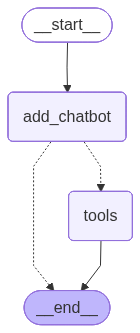

In [30]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
state = graph.invoke({ "messages" : [{ "role": "user", "content": "what is latest price of MSFT?" }] })
print(state["messages"][-1].content)

200.3
